In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# prediction models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
import xgboost as xgb
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import brier_score_loss

#preprocessing
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV

import shap

/Users/tia004/miniforge3/envs/iubdc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/set_a_ml_ready_with_outcomes.csv")

In [3]:
df

,RecordID,in_hospital_death,SAPS-I,SOFA,Length_of_stay,Survival,static_Age,static_Gender,static_Height,static_ICUType,...,TroponinI_missing,TroponinT_missing,Urine_missing,WBC_missing,pH_missing,n_rows_total,n_unique_parameters,n_valid_values,n_missing_minus1_values,Urine_total
0,132539,0,6,1,5,-1,54.0,0.0,NaN,4.0,...,1.0,1.0,0.0,0.0,1.0,273,24,271,2,6500.0
1,132540,0,16,8,8,-1,76.0,1.0,175.3,2.0,...,1.0,1.0,0.0,0.0,0.0,528,32,528,0,6214.0
2,132541,0,21,11,19,-1,44.0,0.0,NaN,3.0,...,1.0,1.0,0.0,0.0,0.0,434,38,433,1,5123.0
3,132543,0,7,1,9,575,68.0,1.0,180.3,3.0,...,1.0,1.0,0.0,0.0,1.0,434,29,434,0,3275.0
4,132545,0,17,2,4,918,88.0,0.0,NaN,3.0,...,1.0,1.0,0.0,0.0,1.0,324,25,322,2,2361.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,142665,0,19,7,10,336,70.0,0.0,NaN,4.0,...,1.0,1.0,0.0,0.0,0.0,447,32,446,1,1980.0
3996,142667,0,8,2,3,-1,25.0,1.0,NaN,3.0,...,1.0,1.0,0.0,0.0,1.0,209,25,208,1,4675.0
3997,142670,0,8,5,11,-1,44.0,1.0,NaN,3.0,...,1.0,1.0,0.0,0.0,0.0,408,35,407,1,4193.0
3998,142671,1,22,10,8,7,37.0,1.0,NaN,3.0,...,1.0,1.0,0.0,0.0,0.0,383,34,382,1,146.0


In [4]:
X_test = pd.read_csv("../data/X_test.csv")
X_train = pd.read_csv("../data/X_train.csv")
y_test = pd.read_csv("../data/y_test.csv")
y_train = pd.read_csv("../data/y_train.csv")

In [5]:
X_train

,BUN_count,BUN_first,BUN_last,BUN_max,BUN_mean,BUN_median,BUN_min,BUN_missing,BUN_std,Creatinine_count,...,pH_mean,pH_median,pH_min,pH_missing,pH_std,static_Age,static_Gender,static_Height,static_ICUType,static_Weight
0,2.0,13.0,8.0,13.0,10.500000,10.5,8.0,0.0,3.535534,2.0,...,7.452670,7.420371,7.341433,1.0,0.171855,54.0,0.0,169.724569,4.0,81.51839
1,3.0,16.0,21.0,21.0,18.333333,18.0,16.0,0.0,2.516611,3.0,...,7.395000,7.400000,7.340000,0.0,0.037796,76.0,1.0,175.300000,2.0,76.00000
2,3.0,8.0,3.0,8.0,4.666667,3.0,3.0,0.0,2.886751,3.0,...,7.495000,7.500000,7.470000,0.0,0.017321,44.0,0.0,169.724569,3.0,56.70000
3,3.0,23.0,10.0,23.0,17.666667,20.0,10.0,0.0,6.806859,3.0,...,7.452670,7.420371,7.341433,1.0,0.171855,68.0,1.0,180.300000,3.0,84.60000
4,2.0,45.0,25.0,45.0,35.000000,35.0,25.0,0.0,14.142136,2.0,...,7.452670,7.420371,7.341433,1.0,0.171855,88.0,0.0,169.724569,3.0,81.51839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,3.0,25.0,25.0,25.0,24.000000,25.0,22.0,0.0,1.732051,3.0,...,7.375625,7.385000,7.260000,0.0,0.066530,78.0,1.0,180.300000,2.0,83.18000
7996,7.0,49.0,60.0,60.0,54.571429,56.0,49.0,0.0,4.429339,7.0,...,7.276667,7.315000,7.040000,0.0,0.114680,90.0,1.0,177.800000,3.0,87.00000
7997,3.0,28.0,32.0,32.0,29.666667,29.0,28.0,0.0,2.081666,3.0,...,7.350000,7.350000,7.350000,0.0,0.000000,70.0,0.0,152.400000,2.0,74.00000
7998,2.0,16.0,12.0,16.0,14.000000,14.0,12.0,0.0,2.828427,2.0,...,7.366667,7.360000,7.340000,0.0,0.030551,49.0,0.0,169.724569,3.0,57.00000


In [6]:
X_test.shape

(4000, 243)

In [7]:
X_train.shape

(8000, 243)

In [8]:
y_test.shape

(4000, 1)

In [9]:
y_train.shape

(8000, 1)

In [10]:
numeric_features = X_train.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features)
    ])

In [11]:
pipe_lr = make_pipeline(preprocessor, LogisticRegression(max_iter=2000, random_state=2))
pipe_lr.fit(X_train, y_train)

/Users/tia004/miniforge3/envs/iubdc/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [12]:
y_pred = pipe_lr.predict(X_test)
y_probs = pipe_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3415
           1       0.62      0.33      0.43       585

    accuracy                           0.87      4000
   macro avg       0.76      0.65      0.68      4000
weighted avg       0.85      0.87      0.86      4000

ROC-AUC Score: 0.8593


In [13]:
pipe_xgb = make_pipeline(preprocessor, XGBClassifier(random_state=123))

param_grid_xgb = {
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
    'xgbclassifier__max_depth': [3, 5, 7],
}

random_search_xgb = RandomizedSearchCV(
    pipe_xgb, param_distributions=param_grid_xgb, 
    n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=123
)

random_search_xgb.fit(X_train, y_train.values.ravel())
print(f"Best XGB Params: {random_search_xgb.best_params_}")
print(f"Best XGB ROC-AUC: {random_search_xgb.best_score_:.4f}")

Best XGB Params: {'xgbclassifier__n_estimators': 100, 'xgbclassifier__max_depth': 5, 'xgbclassifier__learning_rate': 0.1}
Best XGB ROC-AUC: 0.8552


In [14]:
pipe_rf = make_pipeline(preprocessor, RandomForestClassifier(random_state=123))

param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__class_weight': ['balanced', None] 
                                    #for imbalanced mortality data
}

random_search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_grid_rf, 
    n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=123
)

random_search_rf.fit(X_train, y_train.values.ravel())
print(f"Best RF Params: {random_search_rf.best_params_}")
print(f"Best RF ROC-AUC: {random_search_rf.best_score_:.4f}")

Best RF Params: {'randomforestclassifier__n_estimators': 300, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__max_depth': 20, 'randomforestclassifier__class_weight': 'balanced'}
Best RF ROC-AUC: 0.8464


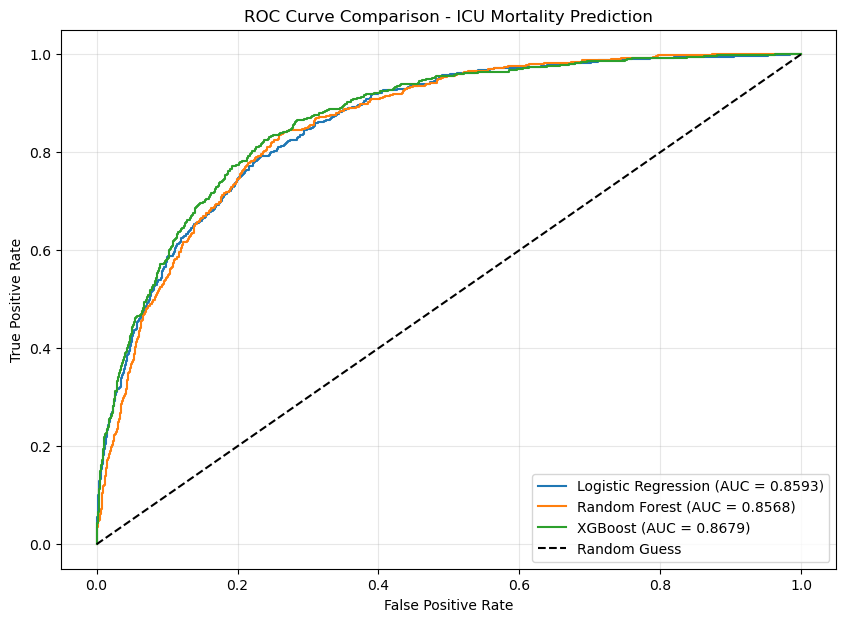

In [15]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(models, X_test, y_test):
    plt.figure(figsize=(10, 7))
    
    for name, model in models.items():
        y_probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison - ICU Mortality Prediction')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Run the plot
models_to_plot = {
    'Logistic Regression': pipe_lr, # Assuming pipe_lr is already fitted
    'Random Forest': random_search_rf.best_estimator_,
    'XGBoost': random_search_xgb.best_estimator_
}

plot_roc_curves(models_to_plot, X_test, y_test)

In [16]:
import shap

# 1. Fit your best model pipeline (using XGBoost as an example)
best_model_pipeline = random_search_xgb.best_estimator_
best_model_pipeline.fit(X_train, y_train.values.ravel())

# 2. Extract the model and the preprocessor from the pipeline
model = best_model_pipeline.named_steps['xgbclassifier']
preprocessor = best_model_pipeline.named_steps['columntransformer']

# 3. Transform your test data so SHAP evaluates the exact matrix the model sees
# We convert it back to a DataFrame to keep your descriptive column names!
X_test_transformed = pd.DataFrame(
    preprocessor.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [17]:
# Initialize tree explainer (works for XGBoost and Random Forest)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your entire test set
shap_values = explainer(X_test_transformed)

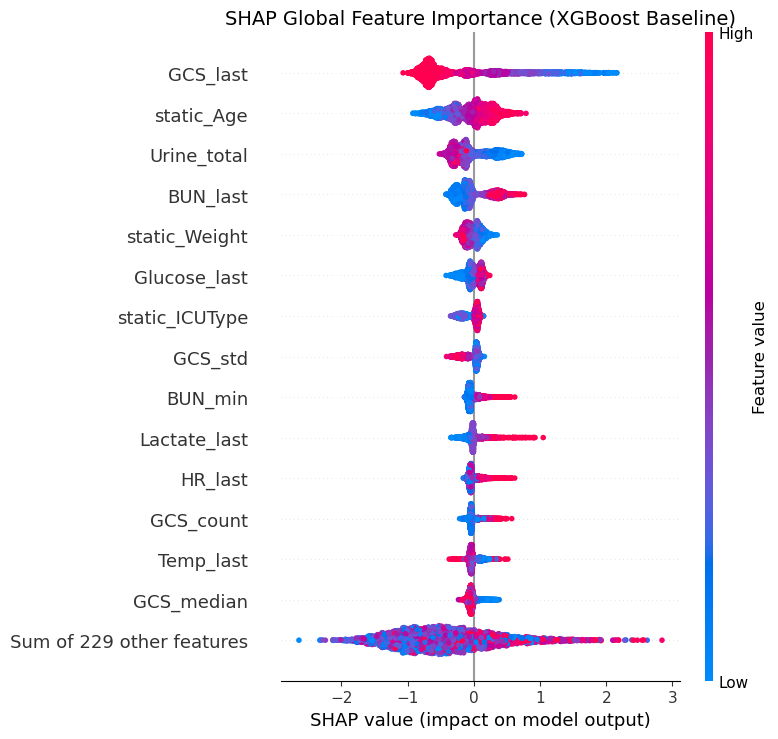

In [18]:
plt.figure(figsize=(10, 8))
plt.title("SHAP Global Feature Importance (XGBoost Baseline)", fontsize=14)

# Generate beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)

plt.tight_layout()
plt.show()

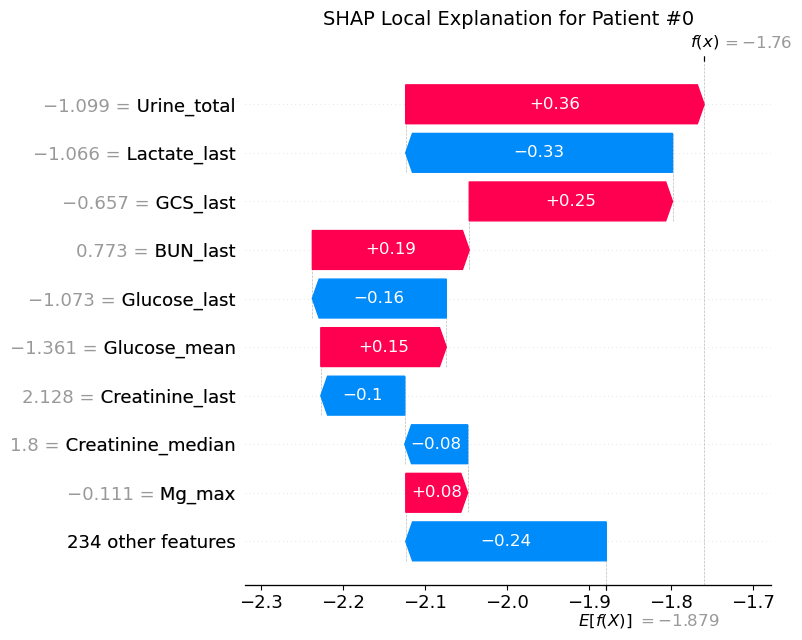

In [19]:
# Let's look at the very first patient in your test set (Patient Index 0)
patient_idx = 0

plt.figure(figsize=(10, 6))

# Generate waterfall plot for this single patient
shap.plots.waterfall(shap_values[patient_idx], max_display=10, show=False)

plt.title(f"SHAP Local Explanation for Patient #{patient_idx}", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
y_true = y_test.values.ravel()


# take [:, 1] to get the prob of positive class (in_hospital_death = 1)
lr_probs = pipe_lr.predict_proba(X_test)[:, 1]
brier_lr = brier_score_loss(y_true, lr_probs)

rf_best = random_search_rf.best_estimator_
rf_probs = rf_best.predict_proba(X_test)[:, 1]
brier_rf = brier_score_loss(y_true, rf_probs)

xgb_best = random_search_xgb.best_estimator_
xgb_probs = xgb_best.predict_proba(X_test)[:, 1]
brier_xgb = brier_score_loss(y_true, xgb_probs)

print(f"Logistic Regression : {brier_lr:.4f}")
print(f"Random Forest       : {brier_rf:.4f}")
print(f"XGBoost             : {brier_xgb:.4f}")


Logistic Regression : 0.0918
Random Forest       : 0.0963
XGBoost             : 0.0896
